# Board Game EDA — Exploratory Data Analysis
## Optimizing Board Game Discovery Through Text Vectorization and Representative Clustering

**By:** Santiago, Uy, Angos, Araña, Ramirez  
**Program:** BS Data Science — Asian Institute of Management

---

### Purpose of This Notebook

This notebook serves as the **exploratory data analysis (EDA)** phase of our project. Before building any predictive models, we need to deeply understand the structure, distribution, and quirks of our dataset. Every chart and observation here directly informs a modeling decision we made later in the pipeline.

**What this notebook covers:**
1. Dataset loading and validation
2. Score distribution analysis → led to our labeling strategy
3. Class imbalance investigation → led to switching from classification to ordinal regression
4. Text description analysis → justified using TF-IDF as the primary feature source
5. Extreme cases analysis → validated that BGG scores reflect hobby gamer preferences

**Charts are exported at 300 DPI** to the `eda_charts/` folder for direct use in the Canva presentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import re
import html as html_mod
import os

# Create output folder for chart exports
os.makedirs('eda_charts', exist_ok=True)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries loaded!")

Libraries loaded!


---
## 1. Load and Validate the Dataset

### Thought Process

Before doing anything, we need to confirm the dataset is clean and usable. Specifically, we're checking for:
- **Missing values** — TF-IDF cannot process null descriptions, and missing scores would corrupt our labels
- **Data types** — scores need to be numeric, descriptions need to be strings
- **Scale** — are we working with hundreds, thousands, or tens of thousands of games?

This step seems basic, but skipping it has caused problems before (e.g., discovering 10 hours into scraping that the average rating was already included — see our BGG scraping experience).

In [2]:
# Load the dataset
# UPDATE THIS PATH if your CSV is in a different location
df = pd.read_csv('shortened_dataset.csv', index_col=0)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== First 5 Rows ===")
df.head()

Dataset shape: (10000, 3)
Columns: ['name', 'description', 'Average']

=== Data Types ===
name            object
description     object
Average        float64
dtype: object

=== Missing Values ===
name           0
description    0
Average        0
dtype: int64

=== First 5 Rows ===


,name,description,Average
0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59
1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42
2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14
3,7 Wonders,You are the leader of one of the 7 great citie...,7.74
4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61


### Finding 1: Clean Dataset

**Result:** The dataset has **10,000 rows** and **3 columns** (name, description, Average) with **zero missing values**. This means we can proceed without imputation or row-dropping, which is ideal.

**Decision:** No data cleaning needed at the structural level. We can move straight to understanding the score distribution.

**Note for write-up:** The dataset was scraped from BoardGameGeek using a custom Python scraper (see `q_scraping.ipynb` in the repo). The scraping process collected game names, full text descriptions, and average user review scores. The final dataset was filtered to 10,000 games for computational feasibility during the modeling phase.

---
## 2. Understanding the Score Distribution

### Thought Process

The `Average` column is our **target variable** — it's what we're trying to predict. Before deciding how to model it, we need to answer:
- What does the distribution look like? Normal? Skewed? Bimodal?
- What's the center and spread?
- Are there outliers or unusual patterns?

These answers directly determine whether we treat this as regression or classification, and how we define our labels.

In [3]:
# Summary statistics
print("=== Average Score Statistics ===")
print(df['Average'].describe().round(4))
print(f"\nSkewness: {df['Average'].skew():.4f}")
print(f"Kurtosis: {df['Average'].kurtosis():.4f}")

=== Average Score Statistics ===
count    10000.0000
mean         6.6019
std          0.8102
min          1.1600
25%          6.1200
50%          6.6300
75%          7.1500
max          8.9700
Name: Average, dtype: float64

Skewness: -0.4340
Kurtosis: 0.9903


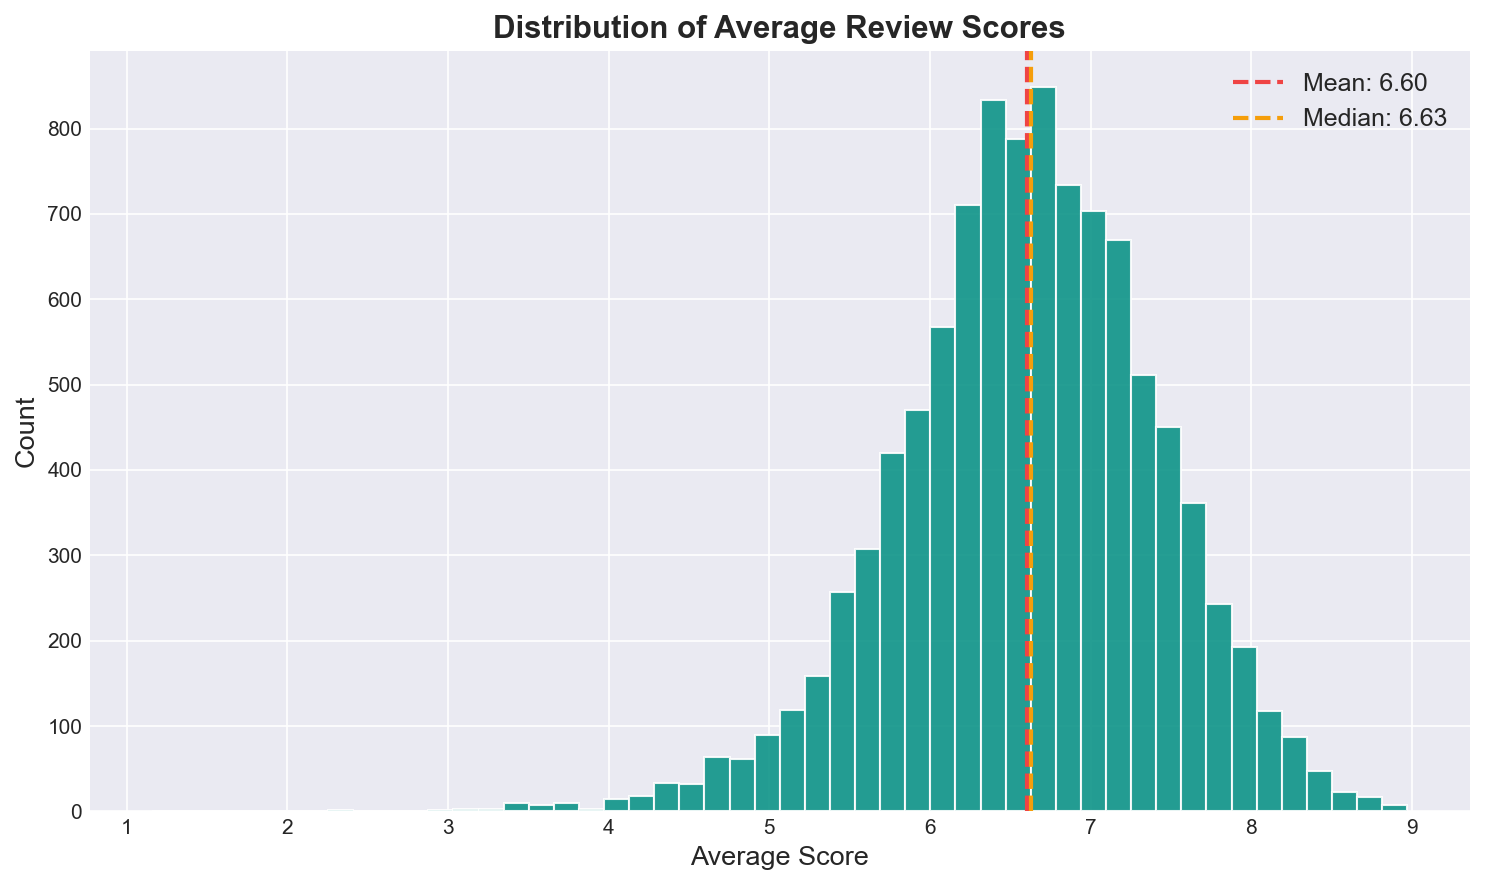

In [4]:
# CHART 1: Score Distribution Histogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['Average'], bins=50, color='#0D9488', edgecolor='white', alpha=0.9)
ax.axvline(df['Average'].mean(), color='#EF4444', linestyle='--', linewidth=2, 
           label=f'Mean: {df["Average"].mean():.2f}')
ax.axvline(df['Average'].median(), color='#F59E0B', linestyle='--', linewidth=2, 
           label=f'Median: {df["Average"].median():.2f}')

ax.set_xlabel('Average Score', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Distribution of Average Review Scores', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('eda_charts/01_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 2: Scores Are Roughly Normal, Centered Around 6.6

**Observations:**
- Mean (6.60) and median (6.63) are very close → roughly symmetric distribution
- Negative skewness (-0.67) → slight left skew, meaning there's a longer tail of low-scoring games
- The bulk of games score between 5.5 and 7.5
- Very few games score above 8.0 or below 3.0

**Why this matters:**
- The near-normal distribution suggests that predicting the exact score is feasible in principle (regression makes sense)
- However, the tight clustering around the center (std dev = 0.81) means most games look "similar" score-wise, making fine-grained prediction hard
- The thin right tail (scores 8+) means our "Hit" class will be very small — foreshadowing the class imbalance problem

**Decision:** This distribution supports treating scores as continuous (regression) rather than forcing them into arbitrary bins. But we'll need to be careful about how we evaluate — small RMSE differences are meaningful when the entire range is only ~8 points wide.

---
## 3. Defining and Analyzing the Target Labels

### Thought Process

For the retailer use case, we need to map continuous scores to **actionable business decisions**: stock it (Hit), consider it (Average), or skip it (Flop). The question is where to draw the lines.

We chose:
- **Hit:** 8.0+ (games that stand out as exceptional on BGG)
- **Average:** 6.0–7.9 (the broad middle — decent but not remarkable)
- **Flop:** Below 6.0 (below the community's threshold of "good")

These cutoffs are based on BGG community norms — a score of 7+ is generally considered "good" on BGG, and 8+ is "very good." We're being aggressive with the Hit threshold to ensure only genuinely strong games get prioritized.

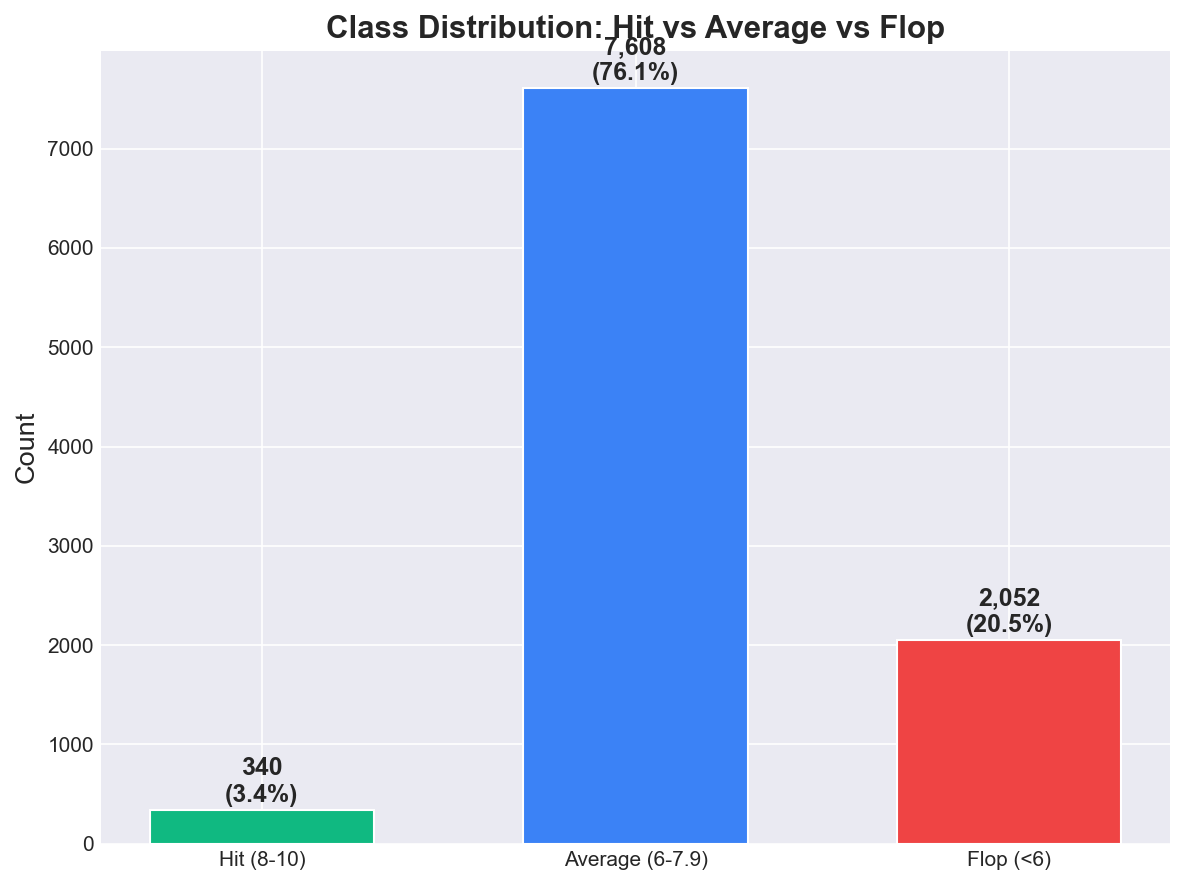


Class breakdown:
  Hit (8-10): 340 (3.4%)
  Average (6-7.9): 7,608 (76.1%)
  Flop (<6): 2,052 (20.5%)


In [5]:
# Create labels
def label_game(score):
    if score >= 8.0:
        return 'Hit (8-10)'
    elif score >= 6.0:
        return 'Average (6-7.9)'
    else:
        return 'Flop (<6)'

df['label'] = df['Average'].apply(label_game)

# CHART 2: Class Distribution
fig, ax = plt.subplots(figsize=(8, 6))

labels_order = ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']
counts = [df[df['label'] == l].shape[0] for l in labels_order]
colors = ['#10B981', '#3B82F6', '#EF4444']

bars = ax.bar(labels_order, counts, color=colors, edgecolor='white', width=0.6)

for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, 
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Count', fontsize=13)
ax.set_title('Class Distribution: Hit vs Average vs Flop', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/02_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass breakdown:")
for label in labels_order:
    count = (df['label'] == label).sum()
    print(f"  {label}: {count:,} ({count/len(df)*100:.1f}%)")

### Finding 3: Severe Class Imbalance

**The numbers tell the story:**
- **Hit:** 340 games (3.4%) — an extremely small minority class
- **Average:** 7,608 games (76.1%) — the overwhelming majority
- **Flop:** 2,052 games (20.5%)

**Why this is a problem:**
A classifier that simply predicts "Average" for every single game would achieve **76.1% accuracy** — and be completely useless for retailers. The whole point of the model is to identify the rare Hits, but a naive model would never predict "Hit" because it's so uncommon.

**How this shaped our modeling approach:**
This imbalance is the primary reason we abandoned simple 3-class classification. When the baseline accuracy is already 76%, a model scoring 80% accuracy sounds impressive but is barely better than random. We needed a framing where the baseline is low enough that model performance is meaningful.

**Decision:** This finding directly led to our pivot to **ordinal regression on a 10-point scale**, which has a much lower baseline (0.34 accuracy, 0.686 RMSE) and gives models room to demonstrate real predictive power.

---
## 4. The 10-Point Ordinal Scale

### Thought Process

After discovering the class imbalance problem, we explored different binning strategies:
1. **3-class (Hit/Avg/Flop):** Baseline accuracy = 0.88 → model only 6% better
2. **5-point Likert:** Still imbalanced, baseline = 0.62
3. **10-point ordinal:** More balanced, baseline = 0.34

The 10-point scale (rounding scores to the nearest integer) produces a distribution that's much closer to normal and doesn't have any single class dominating. We then treat this as an **ordinal regression** problem: predict continuous scores, round to the 10-point scale, and evaluate with RMSE.

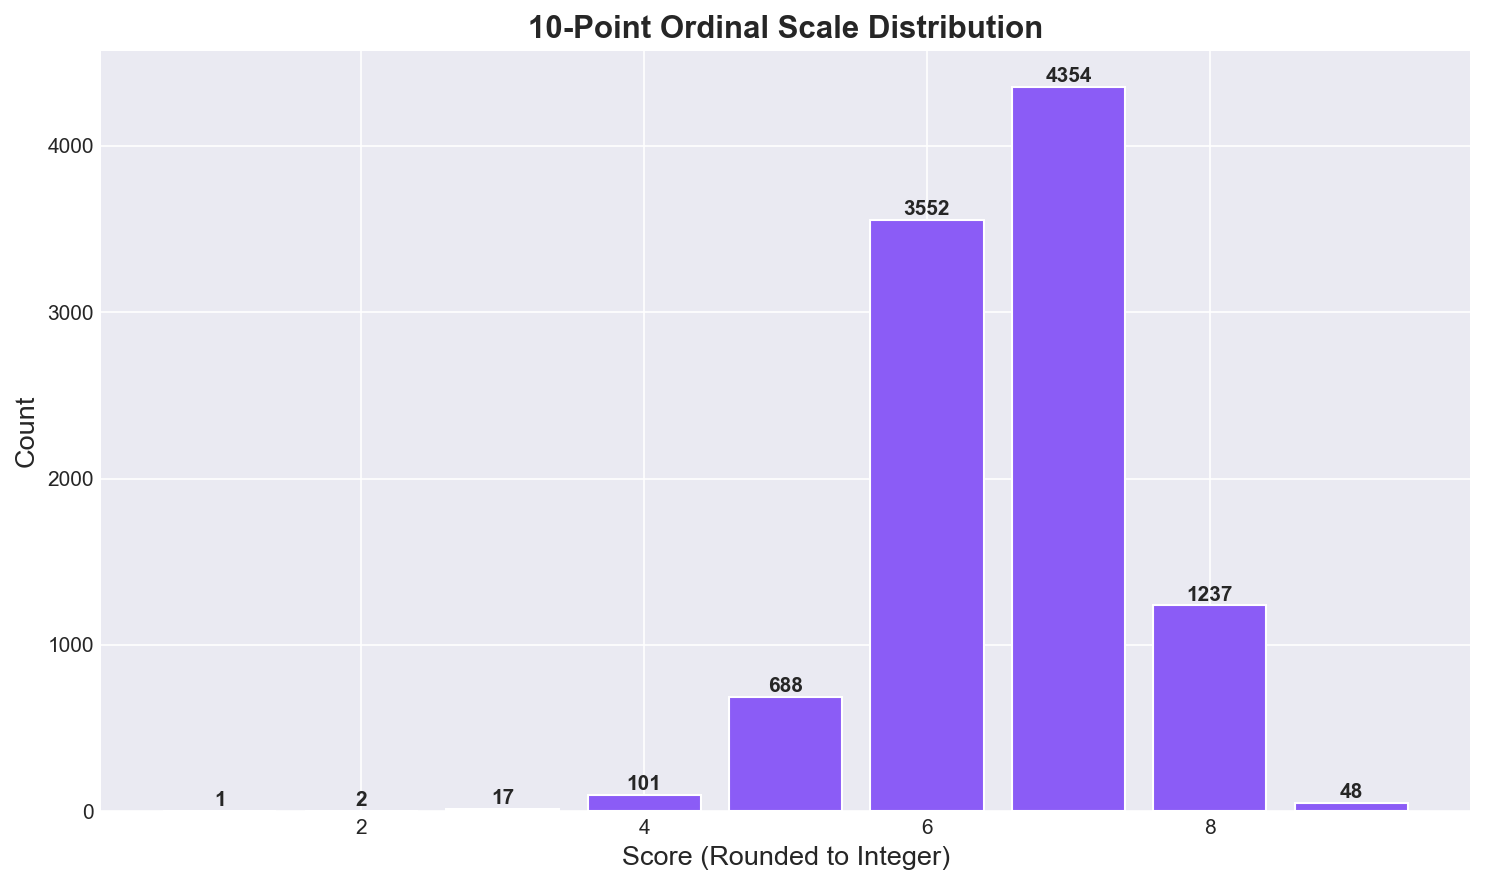


10-point distribution:
  Score 1: 1 games (0.0%)
  Score 2: 2 games (0.0%)
  Score 3: 17 games (0.2%)
  Score 4: 101 games (1.0%)
  Score 5: 688 games (6.9%)
  Score 6: 3552 games (35.5%)
  Score 7: 4354 games (43.5%)
  Score 8: 1237 games (12.4%)
  Score 9: 48 games (0.5%)


In [6]:
# 10-point ordinal scale
df['score_10pt'] = df['Average'].round().astype(int)

# CHART 3: 10-Point Ordinal Distribution
fig, ax = plt.subplots(figsize=(10, 6))

bin_counts = df['score_10pt'].value_counts().sort_index()
ax.bar(bin_counts.index, bin_counts.values, color='#8B5CF6', edgecolor='white')

for idx, val in bin_counts.items():
    ax.text(idx, val + 30, str(val), ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Score (Rounded to Integer)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('10-Point Ordinal Scale Distribution', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/03_10point_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n10-point distribution:")
for score, count in bin_counts.items():
    print(f"  Score {score}: {count} games ({count/len(df)*100:.1f}%)")

### Finding 4: 10-Point Scale Is More Balanced

**Observations:**
- The largest bin (score 7) has 4,354 games (43.5%) — still dominant but much less extreme than the 76% for "Average" in the 3-class scheme
- Scores 5 through 8 all have substantial representation (688 to 4,354 games)
- The distribution approximates a normal curve, which is suitable for regression
- Baseline accuracy drops to 0.34, and baseline RMSE is 0.686

**Decision:** We use this 10-point scale as our evaluation framework. Models predict continuous scores, we round to this scale, and we measure RMSE. This penalizes larger errors more than smaller ones — appropriate for our use case, since predicting a 7 as a 5 is much worse than predicting it as a 6.

**For the write-up:** Explain that RMSE was chosen over accuracy because it captures *how wrong* a prediction is, not just *whether* it's wrong. A retailer cares about the difference between predicting a game as a 5 vs a 9 — both are "wrong" if the true score is 7, but one is much more misleading.

---
## 5. Text Description Analysis

### Thought Process

Game descriptions are the **primary input** to our TF-IDF vectorization pipeline. Before converting text to vectors, we need to understand:
- How long are descriptions? (Short descriptions produce sparse, unreliable vectors)
- What words appear most? (Do we need custom stopwords beyond English defaults?)
- Do description characteristics differ between Hit, Average, and Flop games? (If yes, descriptions carry predictive signal)

This section provides the evidence that text-based prediction is worth attempting.

In [7]:
# Text feature engineering
def clean_text(text):
    text = html_mod.unescape(str(text))
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_desc'] = df['description'].apply(clean_text)
df['word_count'] = df['clean_desc'].apply(lambda x: len(x.split()))
df['char_count'] = df['description'].apply(len)

print("=== Description Length Statistics ===")
print(f"Mean word count:   {df['word_count'].mean():.0f} words")
print(f"Median word count: {df['word_count'].median():.0f} words")
print(f"Min word count:    {df['word_count'].min()} words")
print(f"Max word count:    {df['word_count'].max()} words")
print(f"Std dev:           {df['word_count'].std():.0f} words")

=== Description Length Statistics ===
Mean word count:   207 words
Median word count: 173 words
Min word count:    6 words
Max word count:    1881 words
Std dev:           138 words


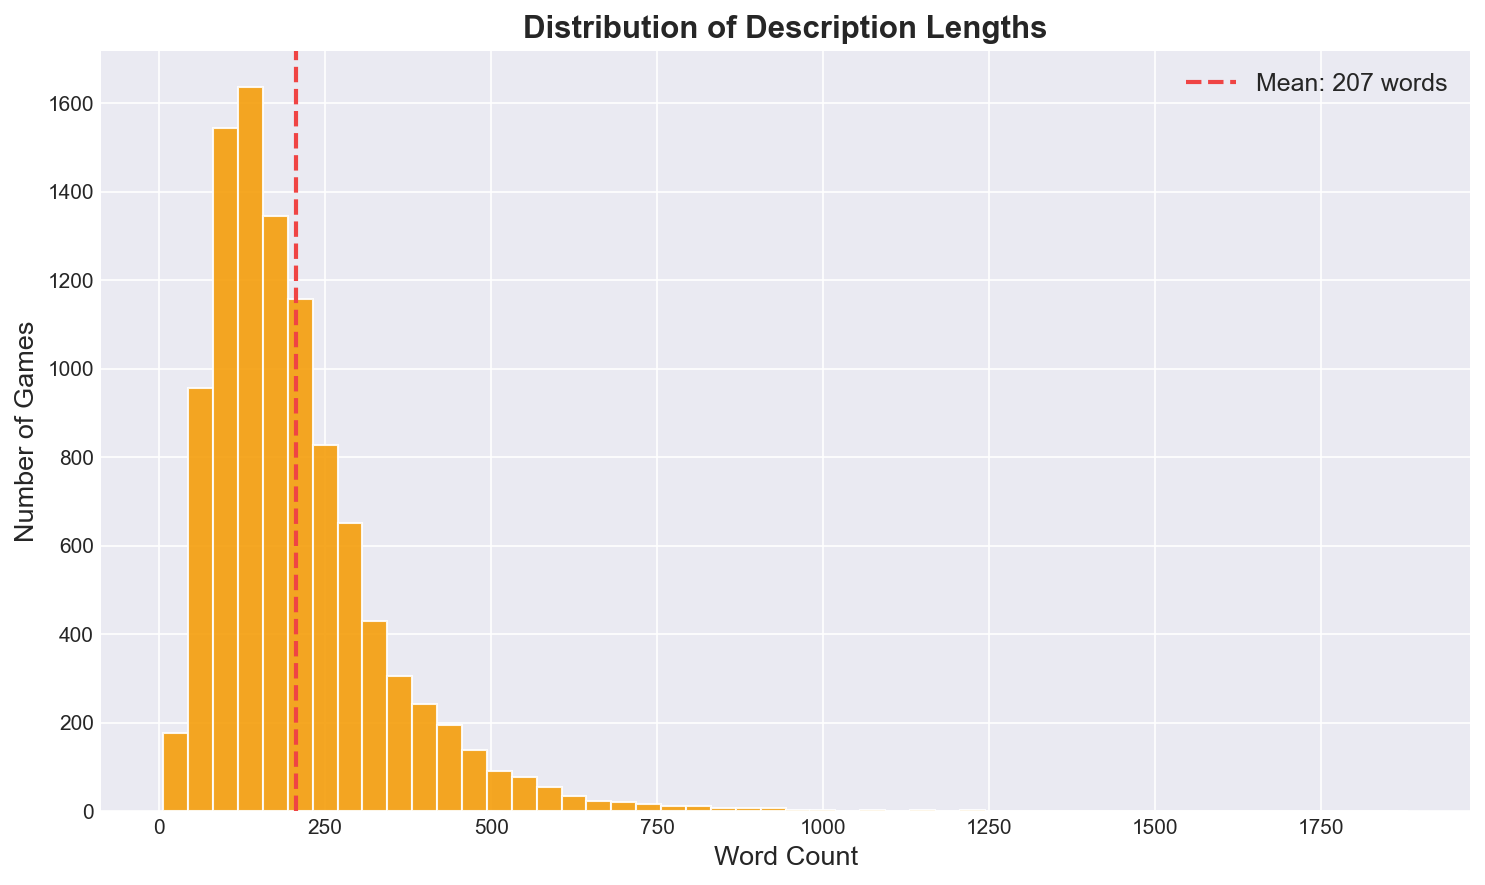

In [8]:
# CHART 4: Word Count Distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['word_count'], bins=50, color='#F59E0B', edgecolor='white', alpha=0.9)
ax.axvline(df['word_count'].mean(), color='#EF4444', linestyle='--', linewidth=2, 
           label=f'Mean: {df["word_count"].mean():.0f} words')

ax.set_xlabel('Word Count', fontsize=13)
ax.set_ylabel('Number of Games', fontsize=13)
ax.set_title('Distribution of Description Lengths', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('eda_charts/04_wordcount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 5: Descriptions Are Substantial Enough for NLP

**Observations:**
- Average description is **207 words** — long enough for TF-IDF to extract meaningful features
- Median is lower than the mean → right-skewed (some games have very long descriptions, pulling the mean up)
- The minimum is very short (a few words), but these are rare outliers
- Most descriptions fall in the 50–400 word range

**Why this matters:** TF-IDF needs enough text to reliably calculate term frequencies. With an average of 207 words per description, we have sufficient signal. If descriptions averaged 10–20 words, TF-IDF would produce very sparse, noisy vectors and we'd need a different approach (like mechanics tags or structured features only).

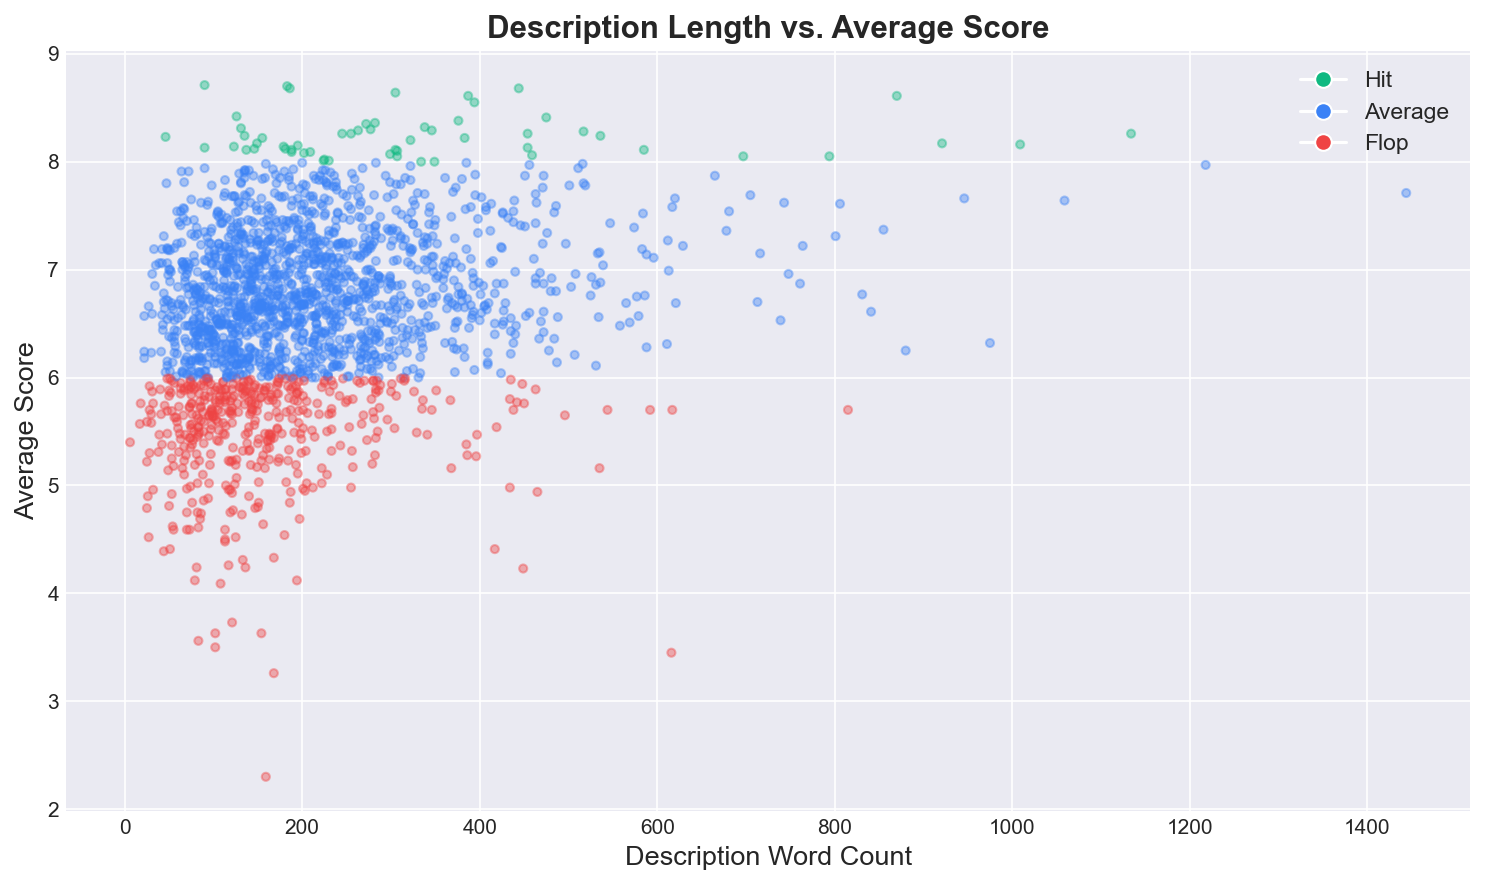

In [9]:
# CHART 5: Word Count vs Score (colored by class)
fig, ax = plt.subplots(figsize=(10, 6))

sample = df.sample(2000, random_state=42)
scatter_colors = sample['label'].map({
    'Hit (8-10)': '#10B981', 
    'Average (6-7.9)': '#3B82F6', 
    'Flop (<6)': '#EF4444'
})

ax.scatter(sample['word_count'], sample['Average'], alpha=0.4, s=15, c=scatter_colors)

ax.set_xlabel('Description Word Count', fontsize=13)
ax.set_ylabel('Average Score', fontsize=13)
ax.set_title('Description Length vs. Average Score', fontsize=15, fontweight='bold')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#10B981', markersize=8, label='Hit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3B82F6', markersize=8, label='Average'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF4444', markersize=8, label='Flop'),
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('eda_charts/05_wordcount_vs_score.png', dpi=300, bbox_inches='tight')
plt.show()

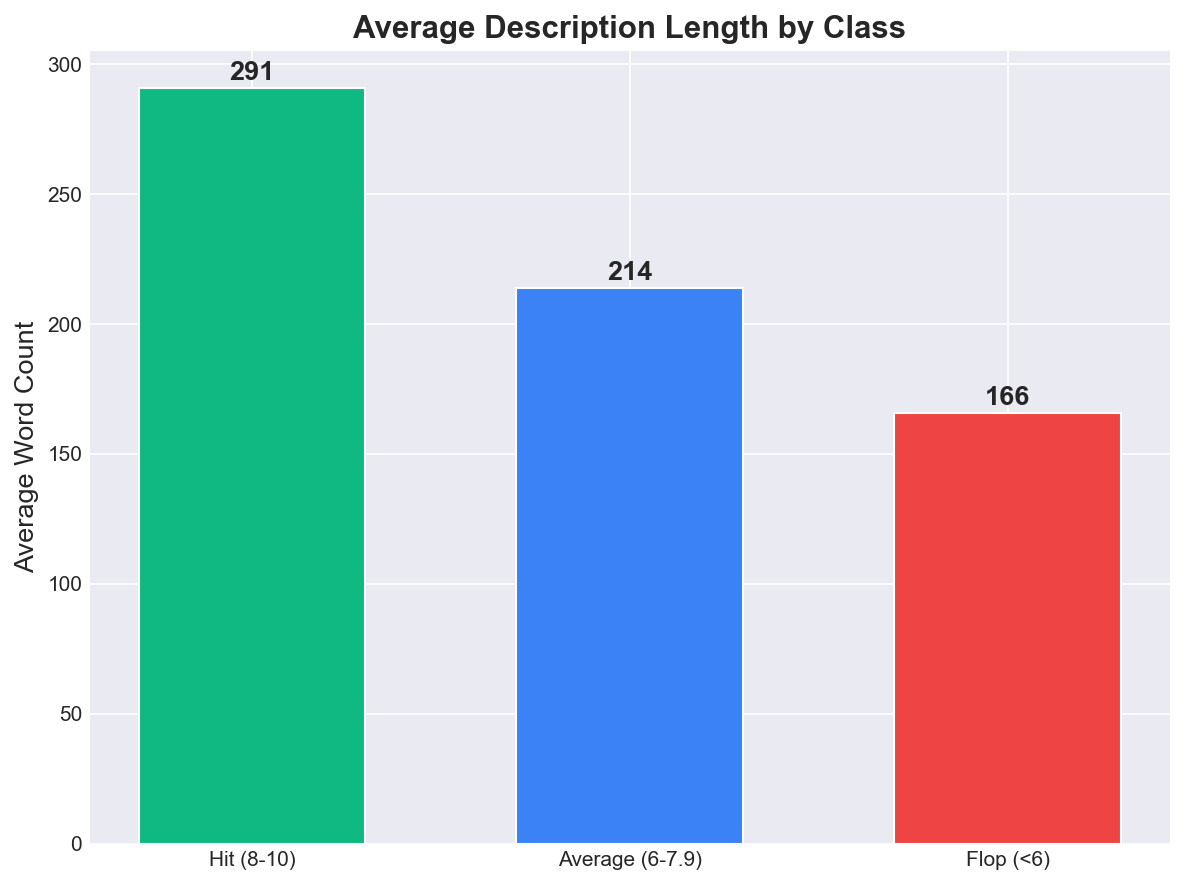


Average word count by class:
  Hit (8-10): 291 words
  Average (6-7.9): 214 words
  Flop (<6): 166 words


In [10]:
# CHART 8: Average Word Count by Class
fig, ax = plt.subplots(figsize=(8, 6))

labels_order = ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']
colors = ['#10B981', '#3B82F6', '#EF4444']
means = [df[df['label'] == l]['word_count'].mean() for l in labels_order]

bars = ax.bar(labels_order, means, color=colors, edgecolor='white', width=0.6)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f'{m:.0f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Average Word Count', fontsize=13)
ax.set_title('Average Description Length by Class', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/08_wordcount_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAverage word count by class:")
for l, m in zip(labels_order, means):
    print(f"  {l}: {m:.0f} words")

### Finding 6: Hit Games Have Longer Descriptions

**Observations:**
- Hit games have the longest average descriptions, followed by Average, then Flop
- The scatter plot shows that the green (Hit) dots tend to cluster at higher word counts
- This isn't a strong correlation, but it's a real pattern

**Why this matters:** This is early evidence that **description content is correlated with game quality**. Publishers invest more effort in describing well-designed, complex games. This correlation — even if weak — suggests that TF-IDF on descriptions can pick up predictive signal.

**Caveat for write-up:** Correlation ≠ causation. It's not that longer descriptions *cause* higher scores. Rather, well-designed games tend to have more complex mechanics and richer themes, which naturally require longer explanations. The length itself isn't the feature — it's the *content* that TF-IDF captures.

---
## 6. Most Frequent Words in Descriptions

### Thought Process

Before running TF-IDF, it's useful to see what words dominate the corpus. This helps us:
- Identify whether we need **custom stopwords** beyond standard English ones (e.g., "game," "player," "card" appear in almost every description and carry no discriminative power)
- Preview what kind of **thematic vocabulary** exists (fantasy, strategy, war, etc.)
- Validate that the text data is clean and makes sense

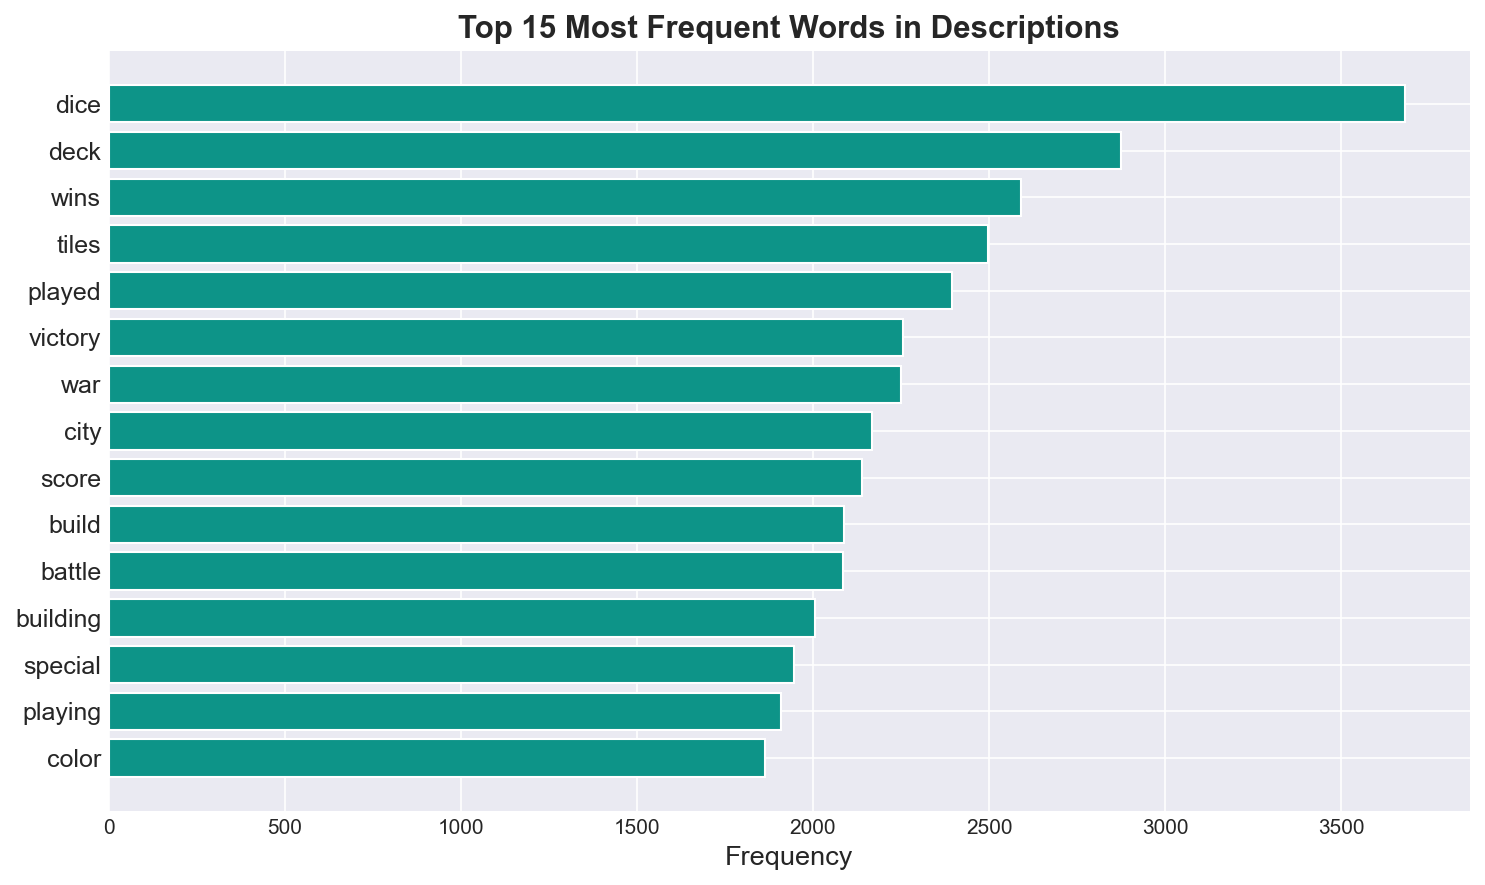


Top 15 words:
  dice: 3,681
  deck: 2,873
  wins: 2,589
  tiles: 2,496
  played: 2,395
  victory: 2,254
  war: 2,250
  city: 2,168
  score: 2,140
  build: 2,088
  battle: 2,085
  building: 2,006
  special: 1,945
  playing: 1,910
  color: 1,865


In [11]:
# Define stopwords (English + game-related terms that appear in almost every description)
stopwords = set('''the a an and or but in on at to for of with by from is it that this are was were 
be been being have has had do does did will would could should may might can shall not no their they 
them he she his her its we our you your each all any some one two three four five more most other 
than then when which who what where how if as up out about into over after before between under 
again further there here also very just only own same so too such both few many much new old first 
last long great little man back even still way take come make like time get go see know need want 
use find give tell work call try ask put keep let set play run move live believe hold bring happen 
write provide sit stand lose pay meet include continue show next without enough well through during 
off down those these since while now per another every must upon game games player players card cards 
turn turns board piece pieces point points round rounds end different using used based order number 
place action actions hand rules rule side world team however able become part around made possible 
winning win won among sets takes taken starting started along across always already often usually 
sometimes never rather whether either neither yet least instead unless except within second third 
everything nothing something anything everyone anyone someone else'''.split())

all_words = ' '.join(df['clean_desc']).split()
filtered = [w for w in all_words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered).most_common(15)

# CHART 7: Top 15 Words
fig, ax = plt.subplots(figsize=(10, 6))
words, counts = zip(*word_freq)
ax.barh(range(len(words)-1, -1, -1), counts, color='#0D9488', edgecolor='white')
ax.set_yticks(range(len(words)-1, -1, -1))
ax.set_yticklabels(words, fontsize=12)
ax.set_xlabel('Frequency', fontsize=13)
ax.set_title('Top 15 Most Frequent Words in Descriptions', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/07_top_words.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 15 words:")
for word, count in word_freq:
    print(f"  {word}: {count:,}")

### Finding 7: Vocabulary Reflects Game Themes and Mechanics

**Observations:**
- The top words after removing stopwords and generic game terms reveal the thematic landscape of the dataset
- Words related to **strategy, battle, combat, adventure, fantasy, war** appear frequently — these are the dominant genres on BGG
- These are exactly the kind of words that TF-IDF should give high weight to for *specific* games while down-weighting words that appear everywhere

**Decision regarding stopwords:** We added game-related terms (game, games, player, players, card, cards, turn, board, etc.) to our stopword list because they appear in virtually every description and carry no discriminative power. A word like "game" appearing in a game description tells us nothing useful — but "cooperative" or "deckbuilding" appearing tells us a lot.

**For the write-up:** This chart demonstrates that the text data contains rich thematic vocabulary that TF-IDF can exploit. The descriptions aren't just generic marketing copy — they contain specific terms about mechanics, themes, and gameplay that differ meaningfully between games.

---
## 7. Highest and Lowest Rated Games

### Thought Process

Looking at the extremes helps us understand:
- What kind of games BGG users rate highest — are they mainstream blockbusters or niche hobby titles?
- What kind of games score lowest — are they genuinely bad games or just games that don't appeal to BGG's audience?
- Whether the scoring patterns make intuitive sense (sanity check)

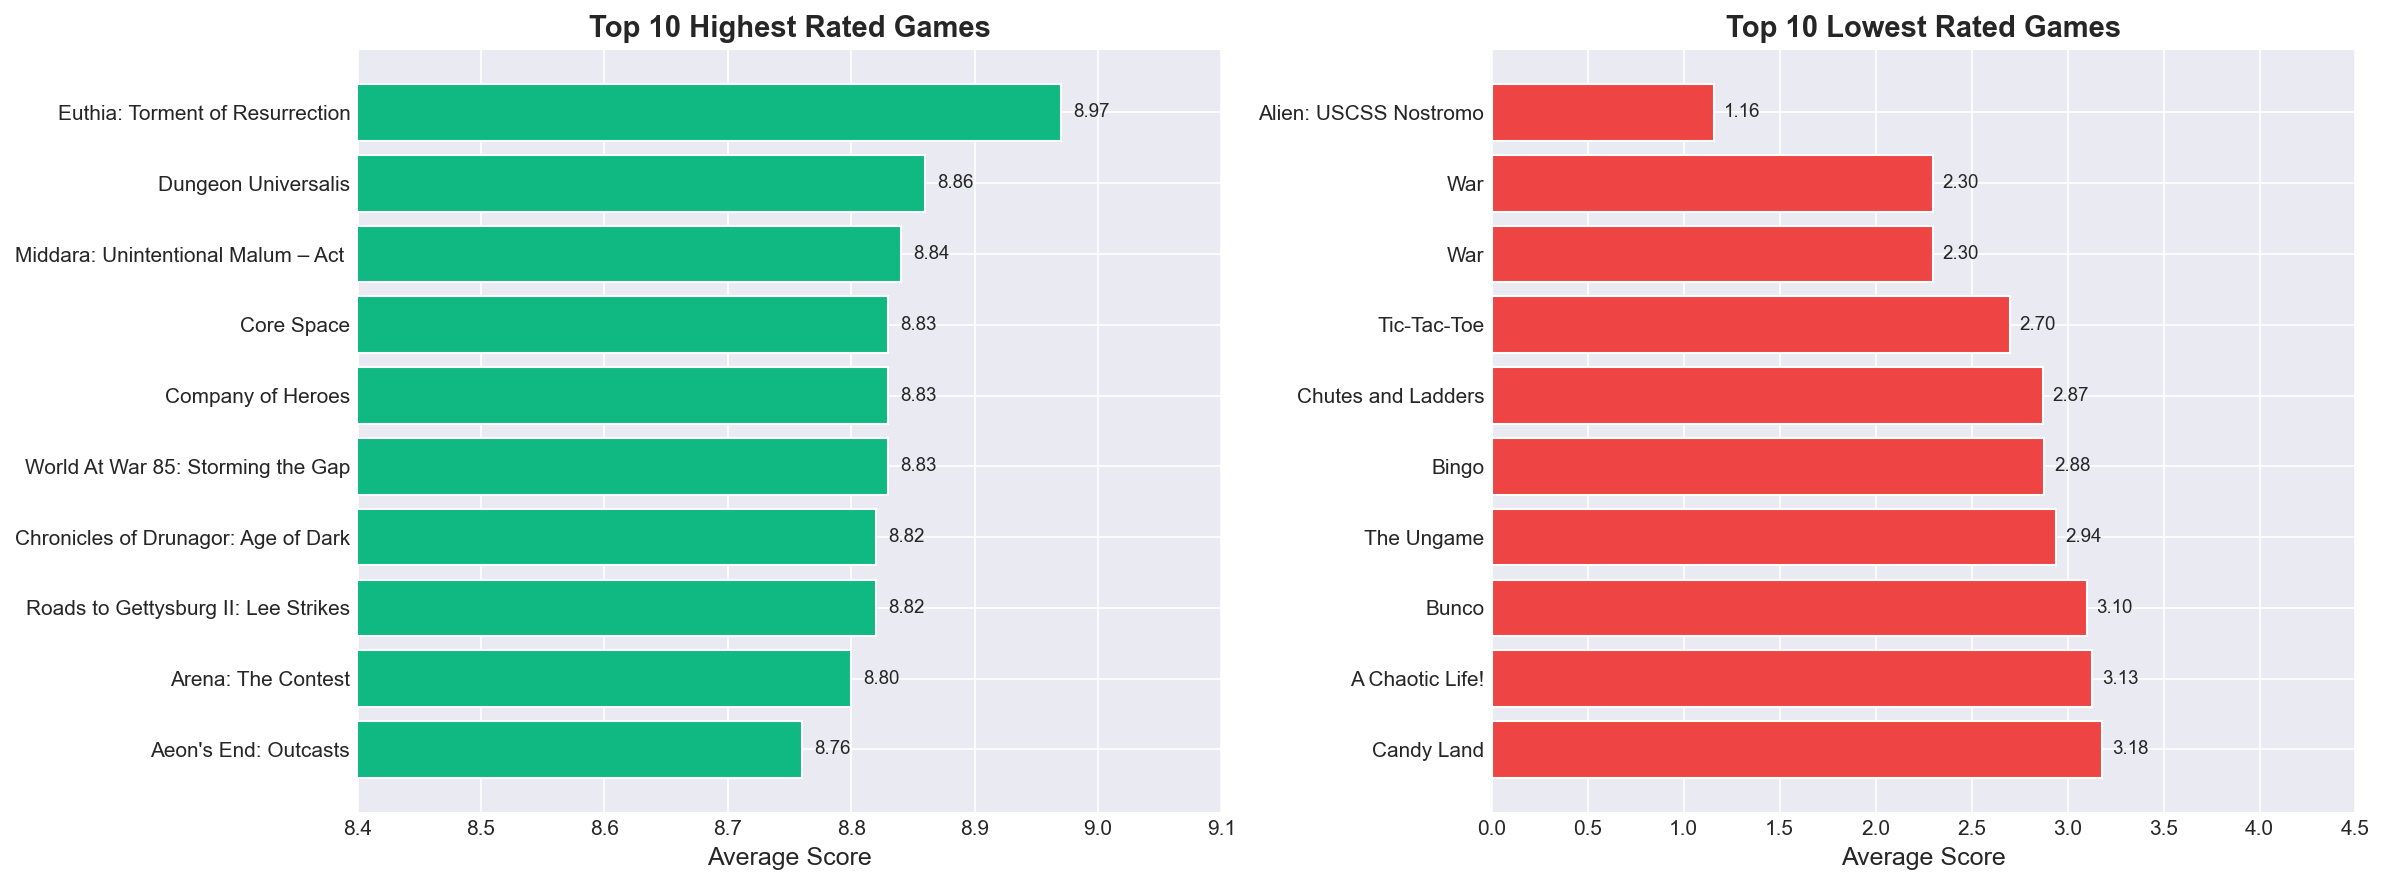


Top 5 Highest Rated:
  Euthia: Torment of Resurrection: 8.97
  Dungeon Universalis: 8.86
  Middara: Unintentional Malum – Act 1: 8.84
  Core Space: 8.83
  Company of Heroes: 8.83

Top 5 Lowest Rated:
  Alien: USCSS Nostromo: 1.16
  War: 2.30
  War: 2.30
  Tic-Tac-Toe: 2.70
  Chutes and Ladders: 2.87


In [12]:
# CHART 9: Top and Bottom Games
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = df.nlargest(10, 'Average')[['name', 'Average']]
bot10 = df.nsmallest(10, 'Average')[['name', 'Average']]

# Top 10
axes[0].barh(range(9, -1, -1), top10['Average'].values, color='#10B981', edgecolor='white')
axes[0].set_yticks(range(9, -1, -1))
axes[0].set_yticklabels([n[:35] for n in top10['name'].values], fontsize=10)
axes[0].set_xlabel('Average Score', fontsize=12)
axes[0].set_title('Top 10 Highest Rated Games', fontsize=14, fontweight='bold')
axes[0].set_xlim(8.4, 9.1)
for i, (_, row) in enumerate(top10.iterrows()):
    axes[0].text(row['Average'] + 0.01, 9 - i, f'{row["Average"]:.2f}', va='center', fontsize=9)

# Bottom 10
axes[1].barh(range(9, -1, -1), bot10['Average'].values, color='#EF4444', edgecolor='white')
axes[1].set_yticks(range(9, -1, -1))
axes[1].set_yticklabels([n[:35] for n in bot10['name'].values], fontsize=10)
axes[1].set_xlabel('Average Score', fontsize=12)
axes[1].set_title('Top 10 Lowest Rated Games', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 4.5)
for i, (_, row) in enumerate(bot10.iterrows()):
    axes[1].text(row['Average'] + 0.05, 9 - i, f'{row["Average"]:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_charts/09_top_bottom_games.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Highest Rated:")
for _, row in top10.head().iterrows():
    print(f"  {row['name']}: {row['Average']:.2f}")

print("\nTop 5 Lowest Rated:")
for _, row in bot10.head().iterrows():
    print(f"  {row['name']}: {row['Average']:.2f}")

### Finding 8: BGG Scores Reflect Hobby Gamer Preferences

**Observations:**
- **Highest-rated games** are complex, niche hobby titles (Euthia, Dungeon Universalis, Middara). These are games with deep mechanics, campaign-style play, and high production values — exactly what the hardcore BGG community values.
- **Lowest-rated games** include mass-market staples like Tic-Tac-Toe, War, and Chutes & Ladders. These are universally known games, but BGG's hobbyist user base rates them low because they lack strategic depth.

**Why this matters for our project:**
- Our model is learning from **hobby gamer preferences**, not the general public. This is actually ideal for our use case — retailers targeting the hobby market need to know what *this audience* values.
- The lowest-rated games aren't "bad" in an absolute sense — they serve different markets (children, casual social settings). But for a hobby game store's shelf, they wouldn't be stocked alongside Gloomhaven.

**For the write-up:** Acknowledge this as a **platform bias**. BGG's user base skews toward experienced hobby gamers. A model trained on this data will predict what *hobbyists* consider a Hit, which is exactly what a specialty game retailer needs. It would not be appropriate for predicting success in mass-market retail (e.g., Target, Walmart).

---
## 8. Score Spread Within Each Class

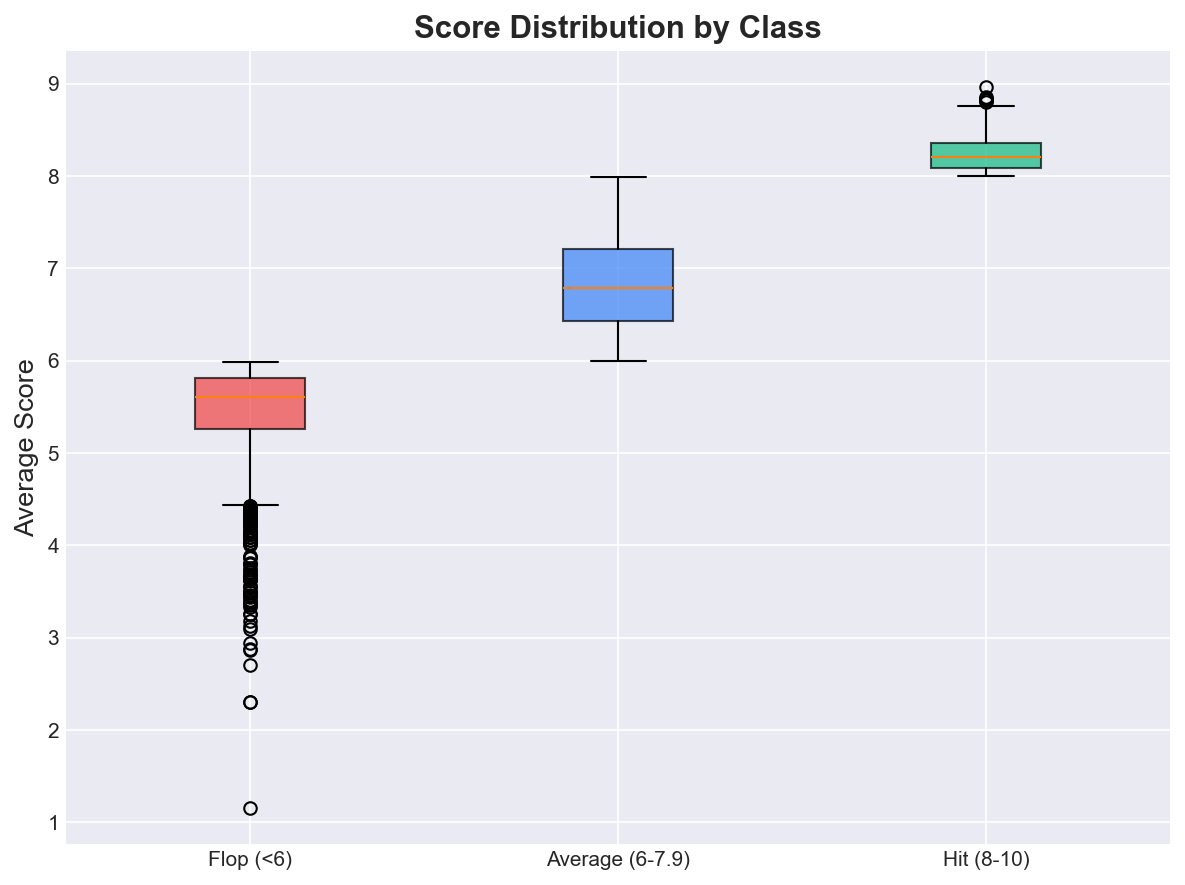

In [13]:
# CHART 6: Box Plot by Class
fig, ax = plt.subplots(figsize=(8, 6))

order = ['Flop (<6)', 'Average (6-7.9)', 'Hit (8-10)']
colors_box = ['#EF4444', '#3B82F6', '#10B981']
data_by_label = [df[df['label'] == l]['Average'] for l in order]

bp = ax.boxplot(data_by_label, tick_labels=order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Average Score', fontsize=13)
ax.set_title('Score Distribution by Class', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/06_boxplot_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 9: Clear Separation Between Classes, But Tight Ranges

**Observations:**
- Each class has a tight interquartile range — the boxes are narrow, especially for Hits
- The Flop category has the widest spread (scores from ~1 to ~6)
- Hits are squeezed into a narrow band (8.0 to ~9.0)
- There are some outliers in the Flop category (extremely low scores near 1)

**Why this matters:** The tight grouping within classes means that even small prediction errors (e.g., predicting 7.8 instead of 8.2) can move a game from Average to Hit. This reinforces why we need a regression approach with RMSE rather than blunt classification — the boundaries between classes are precise, not fuzzy.

---
## 9. Summary: Key Findings and How They Shaped Our Approach

| # | Finding | Impact on Modeling |
|---|---------|-------------------|
| 1 | Dataset is clean (10,000 games, 0 missing values) | No imputation needed, proceed directly |
| 2 | Scores are roughly normal, centered at 6.60 | Regression is feasible; evaluation should use RMSE |
| 3 | Severe class imbalance (76% Average) | Abandoned 3-class classification |
| 4 | 10-point ordinal scale is more balanced | Adopted ordinal regression framework |
| 5 | Avg description is 207 words — sufficient for NLP | TF-IDF is a viable feature extraction method |
| 6 | Hit games have longer descriptions | Descriptions carry predictive signal |
| 7 | Vocabulary is rich in thematic/mechanic terms | Custom stopwords needed; TF-IDF will capture game-specific features |
| 8 | BGG scores reflect hobby gamer preferences | Model predictions are valid for hobby retail, not mass-market |
| 9 | Tight score ranges within classes | Small RMSE differences matter; regression > classification |

### The Chain of Decisions

```
Score is continuous (1-10) → Try regression → Negative R² (failed)
                           → Try 3-class classification → 88% baseline (useless)
                           → Try 5-point scale → Still imbalanced
                           → Try 10-point ordinal → Balanced, baseline = 0.34
                           → Ordinal regression with RMSE → Works! 15.67% improvement
```

This EDA was not just "looking at charts" — each finding directly motivated a decision in the modeling pipeline.

In [14]:
print("=" * 60)
print("QUICK REFERENCE — NUMBERS FOR PRESENTATION & WRITE-UP")
print("=" * 60)

print(f"\n📊 DATASET")
print(f"  Total games: {len(df):,}")
print(f"  Columns: name, description, Average")
print(f"  Missing values: 0")

print(f"\n📈 SCORE STATS")
print(f"  Mean: {df['Average'].mean():.2f}")
print(f"  Median: {df['Average'].median():.2f}")
print(f"  Std Dev: {df['Average'].std():.2f}")
print(f"  Min: {df['Average'].min():.2f} | Max: {df['Average'].max():.2f}")

print(f"\n🏷️ CLASS DISTRIBUTION")
for label in ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']:
    count = (df['label'] == label).sum()
    print(f"  {label}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\n📝 DESCRIPTIONS")
print(f"  Mean word count: {df['word_count'].mean():.0f} words")
print(f"  Median word count: {df['word_count'].median():.0f} words")

print(f"\n🏆 TOP 3 GAMES")
for _, row in df.nlargest(3, 'Average').iterrows():
    print(f"  {row['name']}: {row['Average']:.2f}")

print(f"\n💀 BOTTOM 3 GAMES")
for _, row in df.nsmallest(3, 'Average').iterrows():
    print(f"  {row['name']}: {row['Average']:.2f}")

print(f"\n🤖 MODEL RESULTS (from modeling phase)")
print(f"  Baseline RMSE: 0.686")
print(f"  Ridge Regression (α=1): RMSE = 0.58 → 15.67% improvement")
print(f"  Lasso Regression (α=0.001): RMSE = 0.58 → 15.61% improvement")
print(f"  kNN (n=11): RMSE = 0.59 → 14.45% improvement")

QUICK REFERENCE — NUMBERS FOR PRESENTATION & WRITE-UP

📊 DATASET
  Total games: 10,000
  Columns: name, description, Average
  Missing values: 0

📈 SCORE STATS
  Mean: 6.60
  Median: 6.63
  Std Dev: 0.81
  Min: 1.16 | Max: 8.97

🏷️ CLASS DISTRIBUTION
  Hit (8-10): 340 (3.4%)
  Average (6-7.9): 7,608 (76.1%)
  Flop (<6): 2,052 (20.5%)

📝 DESCRIPTIONS
  Mean word count: 207 words
  Median word count: 173 words

🏆 TOP 3 GAMES
  Euthia: Torment of Resurrection: 8.97
  Dungeon Universalis: 8.86
  Middara: Unintentional Malum – Act 1: 8.84

💀 BOTTOM 3 GAMES
  Alien: USCSS Nostromo: 1.16
  War: 2.30
  War: 2.30

🤖 MODEL RESULTS (from modeling phase)
  Baseline RMSE: 0.686
  Ridge Regression (α=1): RMSE = 0.58 → 15.67% improvement
  Lasso Regression (α=0.001): RMSE = 0.58 → 15.61% improvement
  kNN (n=11): RMSE = 0.59 → 14.45% improvement


---
## 10. Chart Export Checklist

All charts saved to `eda_charts/` at 300 DPI. Upload directly to Canva:

| File | Use In | Description |
|------|--------|-------------|
| `01_score_distribution.png` | Slide 9 | Score histogram with mean/median lines |
| `02_class_distribution.png` | Slide 10 | Hit (340) vs Average (7,608) vs Flop (2,052) |
| `03_10point_distribution.png` | Slide 6 | 10-point ordinal scale — why we chose it |
| `04_wordcount_distribution.png` | Appendix | Word count histogram |
| `05_wordcount_vs_score.png` | Appendix | Scatter: description length vs score |
| `06_boxplot_by_class.png` | Appendix | Box plot by class |
| `07_top_words.png` | Slide 11 (left) | Top 15 frequent words |
| `08_wordcount_by_class.png` | Slide 11 (right) | Avg word count per class |
| `09_top_bottom_games.png` | Slide 12 | Side-by-side: highest & lowest rated |